#### 수영구 기록물 관리시스템 기록물 생산이력 데이터 분석
* 연도별 키워드 빈도분석
* reference source : https://dalulu.tistory.com/108

In [2]:
import pandas as pd
import pandas_profiling
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 기록물 생산이력 데이터 불러오기
df = pd.read_csv("기록물 이용자_생산이력 추가.txt", encoding="utf-8")

In [3]:
# pandas profiling을 통해 EDA실행
pr = df.profile_report()
pr.to_file("(수영구)프로파일링_결과보고서.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

* 결과보고서 검토결과, 생산일자의 히스토그램이 2000~2020년 사이에 집중되어 있음
* 2000년대 데이터 위주로 건제목과 철제목에서 키워드를 추출하여 빈도분석을 진행

In [4]:
# 생산일자 기준 2000년~2020년의 데이터 추출
df_2k = df.loc[(df['생산일자']>=2000) & (df['생산일자']<=2021)].copy()
# 추출결과 확인
df_2k['생산일자'].unique()

array([2012, 2011, 2010, 2009, 2008, 2007, 2006, 2005, 2004, 2003, 2002,
       2000, 2001, 2013, 2014, 2015, 2016, 2019, 2018, 2017, 2020],
      dtype=int64)

In [5]:
# 분석에 필요한 컬럼만 추출 : 문서번호, 생산일자, 건제목
df_2k_ext = df_2k[['문서번호','로그인명','생산일자','건제목']]

* 건제목에서 명사추출
* 명사에 생산일자(연도) 추가

In [6]:
from konlpy.tag import Okt
okt = Okt() # Twitter() → Okt()로 대체

words = []

for i in df_2k_ext.index:
    nounses = okt.nouns(df_2k_ext.loc[i, '건제목']) # 명사추출
    for nouns in nounses:
        if len(nouns) >= 2:
            words.append(nouns + "_" + str(df_2k_ext.loc[i, '생산일자']))
        else:
            pass

* Dict형으로 데이터셋 구성하여, 추출한 명사별 빈도수를 산출
* Dict형으로 구성된 데이터셋을 시각화를 위한 데이터프레임으로 변환
* 데이터프레임 구성 시, tag의 값을 생산연도와 검색으로 분류

In [11]:
from collections import Counter
count = Counter(words)

tag_count = []
#tags = []

for n, c in count.most_common():
    dics = {'tag':n, 'count':c}
    if len(dics['tag']) >= 2:
        tag_count.append(dics)
        #ags.append(dics['tag'])
    else:
        pass
    
df_tags = pd.DataFrame(data=tag_count)
for i in df_tags.index:
    df_tags.loc[i, '생산연도'] = df_tags.loc[i, 'tag'].split('_')[1]
    df_tags.loc[i, '검색어'] = df_tags.loc[i, 'tag'].split('_')[0]
    df_tags.loc[i, '빈도수'] = df_tags.loc[i, 'count']

del df_tags['tag']
del df_tags['count']

df_tags_grp = df_tags.groupby(['생산연도', '검색어'])['빈도수'].sum().reset_index()

# 빈도수가 100미만은 제외
df_tags_grp = df_tags_grp.loc[df_tags_grp['빈도수']>100].copy()
df_tags_grp.to_csv("기록물생산이력_검색어빈도분석결과.csv", sep=",", encoding="utf-8", index=False)

In [12]:
df_tags_grp

,생산연도,검색어,빈도수
28,2000,건축,254.0
46,2000,계획,119.0
57,2000,공사,119.0
197,2000,민락동,131.0
273,2000,사업,121.0
...,...,...,...
29923,2015,알림,146.0
29996,2015,요청,123.0
30217,2015,제출,156.0
32174,2018,계획,142.0


#### 데이터 분할
* 직관적인 시각화 분석결과 도출을 목적으로 분할(시인성 확보)

In [68]:
df_tags_grp

,생산연도,검색어,빈도수
26,2000,건설,69.0
28,2000,건축,254.0
31,2000,검사,78.0
46,2000,계획,119.0
57,2000,공사,119.0
...,...,...,...
33079,2018,협조,61.0
33101,2018,회신,61.0
33341,2019,보고,56.0
33467,2019,신청,54.0


In [54]:
df_tags_grp01 = df_tags_grp.loc[df_tags_grp['생산연도'].str.contains('2000')].copy()
df_tags_grp01.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 107 entries, 15 to 613
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   생산연도    107 non-null    object 
 1   검색어     107 non-null    object 
 2   빈도수     107 non-null    float64
dtypes: float64(1), object(2)
memory usage: 3.3+ KB


#### 시각화

In [37]:
# 라이브러리 불러오기
#from wordcloud import WordCloud, STOPWORDS
from matplotlib import pyplot, rcParams
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = "Malgun Gothic"
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (28, 12)

In [53]:
for i in df_tags_grp01.index:
    word_max = max(df_tags_grp01.loc[i, '빈도수'].astype(str))
    wordcloud = WordCloud(font_path="C:\Windows\Fonts\Malgun Gothic", background_color="white",
                          max_words=word_max, max_font_size=200, height=600, width=800)
    wordcloud.generate(str(df_tags_grp01.loc[i, '검색어']))

plt.imshow(wordcloud, interpolation="lanczos")

TypeError: slice indices must be integers or None or have an __index__ method

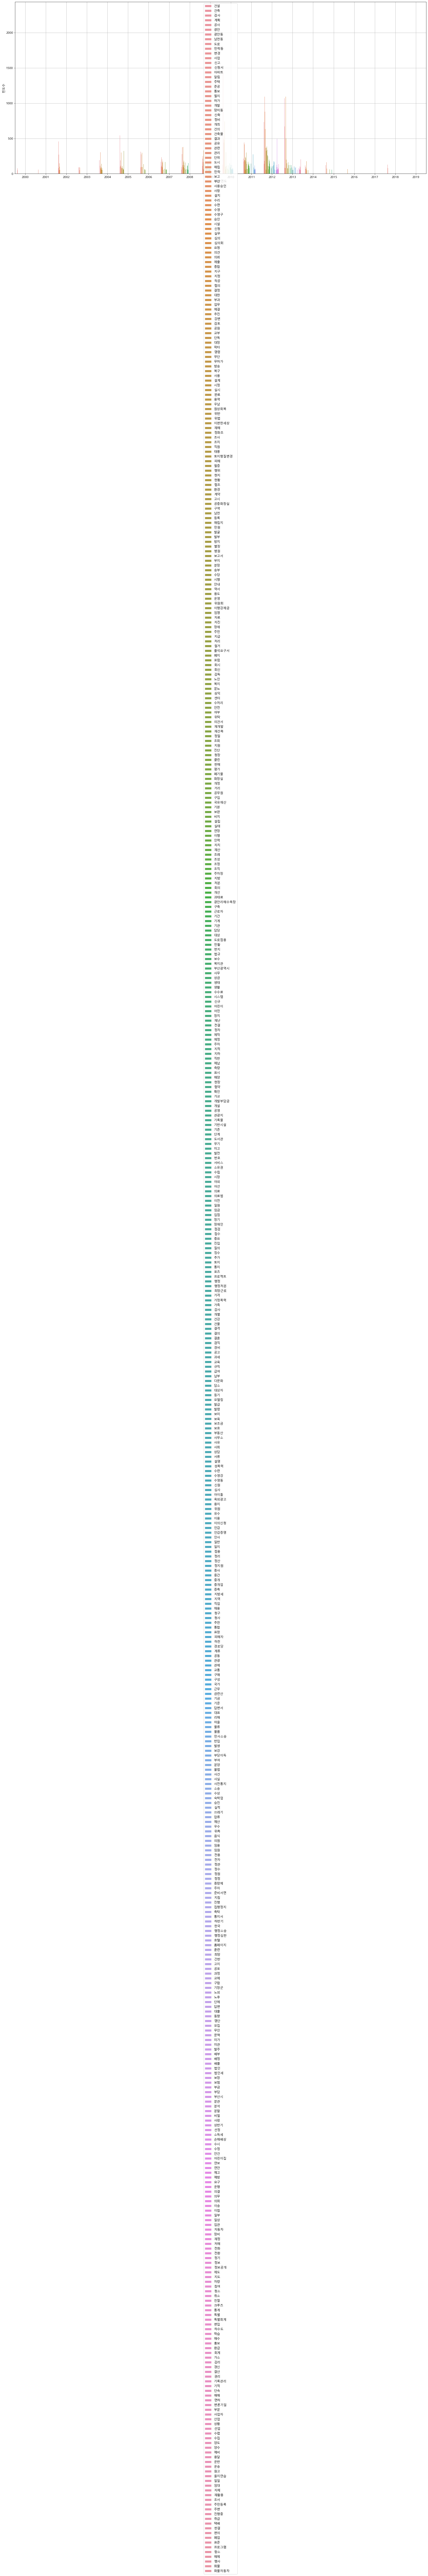

In [69]:
sns.barplot(x='생산연도', y='빈도수', hue='검색어', data=df_tags_grp)
plt.legend(loc="upper center")
plt.grid()